# Cosimita: inertial simulation and occultation

Notebook 00 built sources normalized by flux; notebook 01 built an orbit and
an attitude history around a toy Earth, with the detector nowhere in sight.
This notebook puts the two together and adds the piece neither one had yet:
photons.

Until now every source in the tutorials sat at a fixed **detector-frame**
off-axis angle -- the detector was the centre of the universe, and nothing
moved. `InertialSimulator` flips that around: the sky stands still, sources
live at fixed **inertial** directions, and the spacecraft -- with its orbit
and attitude history from notebook 01 -- moves underneath them. What a
far-field source's off-axis angle *is*, at any moment, now depends on where
the spacecraft is pointing.

**Frame conventions**, stated plainly because everything below depends on
getting them right (plan Section 3.2-3.4):

- `attitude` (`A`): the inertial angle of the detector's own **+y** axis,
  CCW from inertial +X. This is where the spacecraft is pointing.
- `sky_angle` (`lambda`): the inertial direction of a source, CCW from
  inertial +X, pointing *toward* the source. This is where the source is.
- The off-axis angle the detector actually sees is `Nu = A - lambda`: the
  gap between where the instrument points and where the source sits.

Still flatland: the Earth is a circle, the sky is a 1D circle of directions,
angles are the only "solid angle" there is.

A note on which detector this notebook uses: it's **COMPTELito**
(`docs/tutorials/compton_telescopes/01-the_toy_compton_detector.ipynb`), the
same choice notebook 00 made and for the same reason.
`SimpleTraditionalReconstructor` requires the first hit to land in layer
index 0 and treats everything below it as a calorimeter -- true of
COMPTELito's tracker-on-top layout, not of COSIta's uniform stack, whose
layer 0 sits at the *bottom*. There is no reconstructor suited to a
COSIta-like configuration yet, so COMPTELito is what lets the rest of this
notebook show real reconstructed data.

In [1]:
from gammaraytoys import ToyTracker2D
import astropy.units as u
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(0)

# COMPTELito, the traditional (tracker-on-top, calorimeter-below) detector
# from tutorial 01, reused here verbatim -- see the note above for why.
comptelito = ToyTracker2D(material = 'Ge',
                          layer_length = 10*u.m,
                          layer_positions = np.append(300, np.arange(0,10,1))*u.cm,
                          layer_thickness = 1*u.cm,
                          energy_resolution = 0.03,
                          energy_threshold = 20*u.keV)

print(f"throwing_plane_size = {comptelito.throwing_plane_size:.4f}")

throwing_plane_size = 10.4403 m


## 2. The transform, concretely

`gammaraytoys.sims.transform` holds the three formulas of plan Section 3.4,
derived once and shared by every source and by `InertialSimulator` itself.
The one this notebook leans on constantly is `sky_angle_to_offaxis`:
`Nu = A - lambda`, wrapped to `[-180, 180)` degrees.

Two cases are hand-checkable on sight, and are exactly the sanity check the
plan itself gives:

- `A = 90 deg`, `lambda = 90 deg`: the detector's +y axis points along
  inertial +Y, and the source sits in exactly that direction, so it's
  **on-axis**, `Nu = 0`.
- `A = 90 deg`, `lambda = 0 deg`: the source sits along inertial +X, which
  is now `90 deg` around from the detector's +y (CCW), i.e. on the
  detector's **+x side** -- `Nu = 90 deg`.

In [2]:
from gammaraytoys.sims.transform import (sky_angle_to_offaxis, offaxis_to_sky_angle,
                                                 inertial_to_detector_direction)

cases = [
    (90*u.deg, 90*u.deg, 0*u.deg,  "on-axis"),
    (90*u.deg,  0*u.deg, 90*u.deg, "detector's +x side"),
]

for attitude, sky_angle, expected_nu, note in cases:
    nu = sky_angle_to_offaxis(sky_angle, attitude)
    print(f"A = {attitude:>6}, lambda = {sky_angle:>6}  ->  Nu = {nu:>7.2f}   "
          f"({note}, expected {expected_nu})")
    assert np.isclose(nu.to_value(u.deg), expected_nu.to_value(u.deg))

A =   90.0 deg, lambda =   90.0 deg  ->  Nu =    0.00 deg   (on-axis, expected 0.0 deg)
A =   90.0 deg, lambda =    0.0 deg  ->  Nu =   90.00 deg   (detector's +x side, expected 90.0 deg)


That's the whole formula for far-field sources. The one thing worth
proving rather than just asserting is that this new inertial convention
**agrees** with the detector-frame convention every tutorial already uses --
"a source at off-axis angle `Nu` lies along `(sin Nu, cos Nu)`, and the
photon it emits flies along `270 deg - Nu`" (plan Section 3.3).

A far-field photon coming from inertial sky angle `lambda` flies in the
*opposite* inertial direction, `lambda + 180 deg`. Running that through
`inertial_to_detector_direction` (`direction_det = direction_inertial - A +
90 deg`):

```
(lambda + 180) - A + 90 = 270 - (A - lambda) = 270 deg - Nu
```

exactly the existing detector-frame formula. This identity is what
guarantees the two frames can never quietly disagree: any far-field photon
built through the inertial machinery flies in precisely the direction the
detector-frame code has always expected. Let's check it numerically, across
a spread of angles that includes an unwrapped attitude (`450 deg`, past a
full turn) and a negative sky angle, since the identity has to survive both:

In [3]:
rng = np.random.default_rng(1)

n = 5000
sky_angle = (rng.uniform(-720, 720, n)) * u.deg
attitude = (rng.uniform(-720, 720, n)) * u.deg

nu = sky_angle_to_offaxis(sky_angle, attitude)  # wrapped to [-180, 180)

direction_inertial = sky_angle + 180*u.deg
direction_det = inertial_to_detector_direction(direction_inertial, attitude)

# Both sides wrapped to [0, 360) before comparing -- direction_det is
# deliberately left unwrapped by the transform (it has to match the
# existing, also-unwrapped, 270 - offaxis_angle convention), and Nu is
# wrapped to [-180, 180) by sky_angle_to_offaxis, so the raw numbers differ
# by a multiple of 360 deg even though the physical direction is identical.
lhs = direction_det.to_value(u.deg) % 360.0
rhs = (270*u.deg - nu).to_value(u.deg) % 360.0

max_diff = np.max(np.abs(lhs - rhs))
print(f"max |direction_det - (270 deg - Nu)|, mod 360 deg: {max_diff:.2e} deg")

assert max_diff < 1e-9

max |direction_det - (270 deg - Nu)|, mod 360 deg: 1.14e-13 deg


Exact agreement, to floating-point precision, over 5000 random cases
including angles well outside `[0, 360)` on both sides. This is the
guarantee the rest of the notebook leans on: an inertial source's photon,
once thrown, is indistinguishable from a detector-frame photon aimed at the
`Nu` the transform predicts.

## 3. A source that stays put while the spacecraft turns

This is the central point of the whole notebook: **the sky doesn't move,
the instrument does.** A `PointSource` built with `sky_angle` sits at one
fixed inertial direction for its entire life. As the spacecraft's attitude
changes, the off-axis angle that source appears at changes right along with
it -- not because the source moved, but because the detector's own +y axis
is pointing somewhere new.

Let's pick up the 550 km circular orbit from notebook 01 and fly a
zenith-pointing spacecraft around it -- `ZenithPointing` sets `A = theta`,
so over one full orbit the attitude sweeps smoothly through all 360 degrees,
which is exactly what will make the sweep below easy to see.

In [4]:
from gammaraytoys.sims import Earth, SpacecraftHistory, ZenithPointing

earth = Earth()
altitude = 550*u.km
semi_major_axis = earth.radius + altitude

history = SpacecraftHistory.from_elliptical_orbit(
    semi_major_axis = semi_major_axis, time_step = 30*u.s,
    observation_strategy = ZenithPointing(), earth = earth)

rho = earth.angular_radius(semi_major_axis)

print(f"nintervals      = {history.nintervals}")
print(f"total_livetime  = {history.total_livetime:.1f}")
print(f"rho             = {rho:.3f}  (Earth's angular radius at this altitude)")

nintervals      = 191
total_livetime  = 5738.9 s
rho             = 67.016 deg  (Earth's angular radius at this altitude)


Now a source: the same `sky_angle = 40 deg` notebook 01 used for its
`TargetedPointing` demo, so this is literally the source that spacecraft was
tracking. Here it's built with a plain `sky_angle` -- no attitude tracking,
just a fixed point on the sky -- so `InertialSimulator` will see it drift
in and out of view as the zenith-pointing spacecraft's attitude sweeps past
it.

One gotcha worth hitting deliberately before running anything: `PointSource
.random_photon(detector, pose=None, earth=None)` takes the pose as its
second parameter (keeping `detector` first-positional-or-keyword, as the
tutorials require) and the Earth as its third. A `sky_angle` source is
**occultable** by default, so calling it with a `pose` but no `earth` is a
configuration error, not a silent default -- it raises rather than quietly
assuming some `Earth()` that might not match the rest of the run:

In [5]:
from gammaraytoys.sims import PointSource, MonoenergeticSpectrum

target = PointSource(sky_angle = 40*u.deg,
                     spectrum = MonoenergeticSpectrum(1*u.MeV),
                     flux = 1/u.cm/u.s)

pose = next(iter(history))

try:
    target.random_photon(comptelito, pose)  # pose given, earth omitted
except ValueError as err:
    print(f"ValueError: {err}")

ValueError: PointSource is occultable and was given a pose (inertial mode), so it needs an `earth` to test occultation against. Pass `earth`, e.g. the same `Earth` the spacecraft history was built with.


Exactly as documented. `InertialSimulator` always supplies both, so
this only bites when calling `random_photon` by hand -- which is worth
knowing before it does.

Now the real run. `flux` is tuned so the *unocculted* expected count over
this orbit is a round number, using `simulated_rate = flux *
throwing_plane_size` (section 5.2 of the plan) times the total livetime:

In [6]:
from gammaraytoys.sims import InertialSimulator, SimpleTraditionalReconstructor

sky_angle = 40*u.deg
mu_target = 800.0
flux = (mu_target / (comptelito.throwing_plane_size * history.total_livetime)).to(1/u.cm/u.s)

source = PointSource(sky_angle = sky_angle,
                     spectrum = MonoenergeticSpectrum(1*u.MeV),
                     flux = flux)

reco = SimpleTraditionalReconstructor()
sim = InertialSimulator(detector = comptelito, sources = source, reconstructor = reco,
                        spacecraft_history = history, earth = earth)

events = list(sim.run_events())

print(f"unocculted mean mu = {mu_target:.0f}  ->  drawn {sim.nsim + sim.noccult}, "
      f"launched {sim.nsim} (occulted {sim.noccult})")

  0%|          | 0/799.999999999999 [00:00<?, ?it/s]

  2%|▏         | 16/799.999999999999 [00:00<00:04, 157.99it/s]

  4%|▍         | 34/799.999999999999 [00:00<00:04, 169.00it/s]

  6%|▋         | 51/799.999999999999 [00:00<00:05, 147.82it/s]

  8%|▊         | 67/799.999999999999 [00:00<00:04, 147.78it/s]

...

 43%|████▎     | 344/799.999999999999 [00:01<00:01, 336.02it/s]

 83%|████████▎ | 663/799.999999999999 [00:01<00:00, 1151.36it/s]

 98%|█████████▊| 782/799.999999999999 [00:02<00:00, 648.29it/s] 

 99%|█████████▉| 791/799.999999999999 [00:02<00:00, 335.61it/s]

unocculted mean mu = 800  ->  drawn 791, launched 509 (occulted 282)


Now the payoff. For every photon actually launched, recover its
off-axis angle from the thrown direction the same way `run_binned` already
does it internally (`Nu = 270 deg - direction`), and pair it with the
attitude of the interval it was thrown from. `run_events` doesn't hand back
the pose directly, so intervals are looked up by timestamp -- each event's
time falls in exactly one `[start_time, stop_time)` span.

In [7]:
intervals = list(history)
interval_starts = np.array([iv.start_time.to_value(u.s) for iv in intervals])
interval_attitudes = np.array([iv.attitude.to_value(u.deg) for iv in intervals])

def wrap180(angle_deg):
    return (angle_deg + 180.0) % 360.0 - 180.0

times = np.array([t.to_value(u.s) for t, _, _, _ in events])
nu_thrown = np.array([(270*u.deg - sim_event.direction).to_value(u.deg)
                      for _, _, sim_event, _ in events])

# Interval i spans [start_i, start_{i+1}); searchsorted(..., side='right') - 1
# finds that i directly from the sorted start times.
idx = np.searchsorted(interval_starts, times, side = 'right') - 1
attitude_at_event = interval_attitudes[idx]

residual = wrap180(attitude_at_event - nu_thrown - sky_angle.to_value(u.deg))

print(f"attitude swept from {attitude_at_event.min():.1f} to {attitude_at_event.max():.1f} deg")
print(f"max |A - Nu - lambda| = {np.max(np.abs(residual)):.2e} deg")

attitude swept from 0.0 to 358.1 deg
max |A - Nu - lambda| = 5.68e-14 deg


Zero, to floating-point precision, over every single photon this run
launched -- not a statistical near-match, an identity. Let's see what that
identity looks like: `Nu` sweeping with the attitude on the left, and
`A - Nu` sitting dead flat at `lambda = 40 deg` on the right.

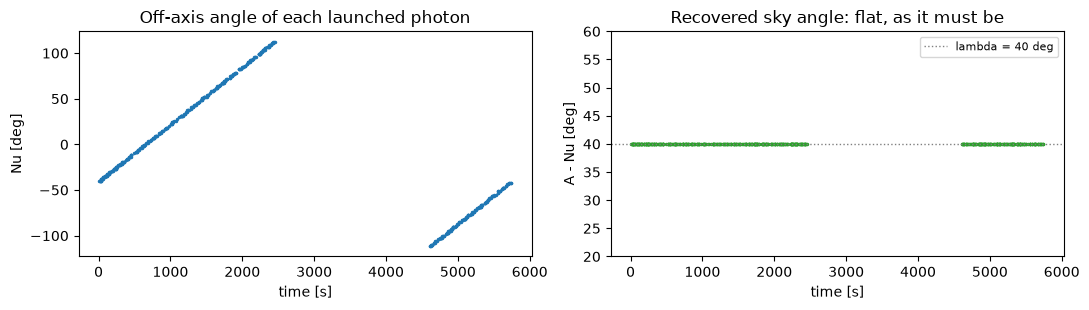

In [8]:
fig, ax = plt.subplots(figsize = (11, 3.2), ncols = 2)

ax[0].plot(times, wrap180(nu_thrown), '.', ms = 3, color = 'tab:blue')
ax[0].set_xlabel('time [s]')
ax[0].set_ylabel('Nu [deg]')
ax[0].set_title('Off-axis angle of each launched photon')

ax[1].plot(times, wrap180(attitude_at_event - nu_thrown), '.', ms = 3, color = 'tab:green')
ax[1].axhline(sky_angle.to_value(u.deg), color = 'gray', ls = ':', lw = 1,
              label = f'lambda = {sky_angle:.0f}')
ax[1].set_xlabel('time [s]')
ax[1].set_ylabel('A - Nu [deg]')
ax[1].set_ylim(sky_angle.to_value(u.deg) - 20, sky_angle.to_value(u.deg) + 20)
ax[1].set_title('Recovered sky angle: flat, as it must be')
ax[1].legend(loc = 'upper right', fontsize = 8)

fig.tight_layout()

`Nu` sweeps across the full range as the attitude turns underneath
the source -- gaps in the sweep are the stretches where the source was
behind the Earth and no photon was launched at all, taken up in section 4.
`A - Nu` is the same data, just rearranged to undo the sweep: a flat line at
`40 deg`, because that's what it algebraically has to be. The source never
moved; only the instrument did.

## 4. Occultation

### 4.1 The duty cycle over a full orbit

For a circular orbit, occultation of a fixed-sky-angle source has a clean
closed form (plan Section 7, PR 3): nadir sweeps the full `360 deg` once per
orbit, and the source is blocked whenever nadir passes within `rho` of it --
an arc of `2 rho` out of `2 pi`, so the occulted **duty cycle** is `rho /
pi`, independent of where on the sky the source actually sits. This is pure
geometry, the same `Earth.is_occulted` check notebook 01 used, with no
detector or simulator involved at all. Let's fly a *full* orbit (rather than
the earlier run's partial one) and check it:

rho                          = 67.0159 deg
occulted duty cycle, numeric = 0.3717
occulted duty cycle, rho/pi  = 0.3723
relative difference          = 0.16%


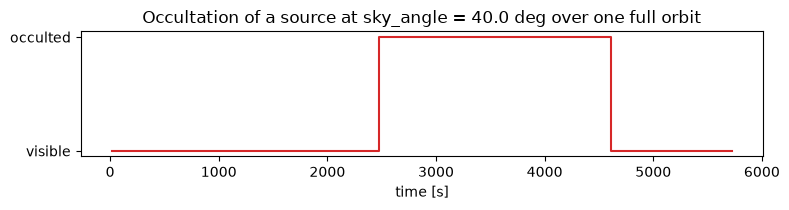

In [9]:
full_history = SpacecraftHistory.from_elliptical_orbit(
    semi_major_axis = semi_major_axis, time_step = 30*u.s,
    observation_strategy = ZenithPointing(), earth = earth)

full_intervals = list(full_history)
t_mid = u.Quantity([iv.mid_time for iv in full_intervals])
orbit_angle = u.Quantity([iv.orbit_angle for iv in full_intervals])
orbit_radius = u.Quantity([iv.orbit_radius for iv in full_intervals])

occulted = earth.is_occulted(sky_angle, orbit_angle, orbit_radius)

fig, ax = plt.subplots(figsize = (8, 2.2))
ax.step(t_mid.to_value(u.s), occulted.astype(int), where = 'post', color = 'tab:red')
ax.set_xlabel('time [s]')
ax.set_yticks([0, 1])
ax.set_yticklabels(['visible', 'occulted'])
ax.set_title(f'Occultation of a source at sky_angle = {sky_angle} over one full orbit')
fig.tight_layout()

duty_numeric = np.mean(occulted)
duty_analytic = (rho / (180*u.deg)).to_value(u.dimensionless_unscaled)  # rho/pi, rho in radians

print(f"rho                          = {rho:.4f}")
print(f"occulted duty cycle, numeric = {duty_numeric:.4f}")
print(f"occulted duty cycle, rho/pi  = {duty_analytic:.4f}")
print(f"relative difference          = {abs(duty_numeric - duty_analytic) / duty_analytic:.2%}")

They agree to well under a percent -- the residual is just the
`30 s` time step discretizing exactly when the limb crossings fall.

### 4.2 The visible wedge: where an `IsotropicSource` loses photons

A single fixed-sky-angle source gives an on/off signal, but the clearest
picture of occultation comes from a source that covers the *whole* sky at
once: an `IsotropicSource`, frozen at one pose. From the spacecraft, the
Earth carves a wedge of width `2 rho` out of the sky, centred on nadir. In
the detector frame that wedge sits at

```
Nu = A - nadir = A - (theta + 180 deg)
```

-- the same reflection `lambda -> Nu = A - lambda` that makes any inertial
geometry legible in the detector frame (section 2 above), just applied to
the nadir direction instead of a source direction.

Let's freeze a pose with a *non-trivial* attitude -- `orbit_angle = 0 deg`,
`attitude = 50 deg` -- specifically so the wedge isn't centred on `Nu = 0`
by coincidence (with `ZenithPointing`, `A = theta` always, so the wedge
would sit at the same `Nu = -180 deg` at every pose -- true, but it would
hide whether the formula above is really using `A` and not just `theta`).

In [10]:
from gammaraytoys.sims import SpacecraftInterval

frozen_orbit_angle = 0*u.deg
frozen_attitude = 50*u.deg

pose = SpacecraftInterval(start_time = 0*u.s, stop_time = 1*u.s, livetime = 1*u.s,
                          orbit_radius = semi_major_axis,
                          orbit_angle = frozen_orbit_angle, attitude = frozen_attitude)

nadir = frozen_orbit_angle + 180*u.deg
expected_center = wrap180((frozen_attitude - nadir).to_value(u.deg))
expected_halfwidth = rho.to_value(u.deg)

print(f"nadir            = {nadir}")
print(f"expected centre  = Nu = {expected_center:.2f} deg")
print(f"expected width   = 2 rho = {2*expected_halfwidth:.2f} deg")

nadir            = 180.0 deg
expected centre  = Nu = -130.00 deg
expected width   = 2 rho = 134.03 deg


In [11]:
from gammaraytoys.sims import IsotropicSource

isotropic = IsotropicSource(spectrum = MonoenergeticSpectrum(1*u.MeV), flux = 1/u.cm/u.s)

n_draws = 8000
nu_survivors = []
n_occulted = 0

for _ in range(n_draws):
    photon = isotropic.random_photon(comptelito, pose, earth)
    if photon is None:
        n_occulted += 1
        continue
    nu_survivors.append((270*u.deg - photon.direction).to_value(u.deg) % 360.0)

nu_survivors = np.sort(np.array(nu_survivors))
print(f"{n_draws} draws: {n_occulted} occulted, {len(nu_survivors)} survived "
      f"({n_occulted/n_draws:.1%} occulted, vs rho/pi = {duty_analytic:.1%})")

# The occulted arc is the one gap in an otherwise uniform coverage of the
# sky -- find it as the single largest gap between consecutive survivors
# (wrapping around 360 -> 0), purely from the data, with no reference to the
# analytic formula above.
gaps = np.diff(nu_survivors)
wrap_gap = 360.0 - nu_survivors[-1] + nu_survivors[0]
widest = np.argmax(np.append(gaps, wrap_gap))
if widest < len(gaps):
    gap_lo, gap_hi = nu_survivors[widest], nu_survivors[widest + 1]
else:
    gap_lo, gap_hi = nu_survivors[-1], nu_survivors[0] + 360.0

empirical_width = gap_hi - gap_lo
empirical_center = wrap180(gap_lo + empirical_width / 2)

print(f"empirical centre = {empirical_center:.2f} deg   (predicted {expected_center:.2f})")
print(f"empirical width  = {empirical_width:.2f} deg   (predicted {2*expected_halfwidth:.2f})")

8000 draws: 3015 occulted, 4985 survived (37.7% occulted, vs rho/pi = 37.2%)
empirical centre = -130.02 deg   (predicted -130.00)
empirical width  = 134.12 deg   (predicted 134.03)


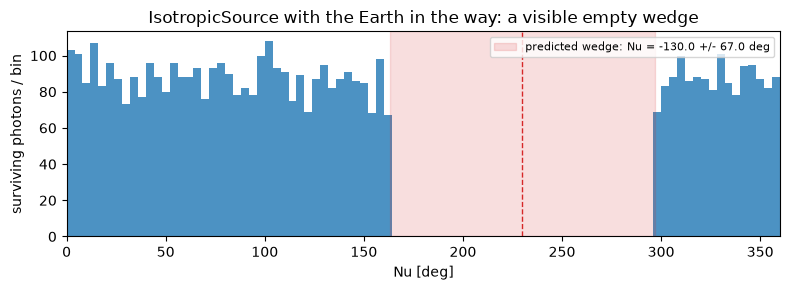

In [12]:
# Plotted on [0, 360) rather than wrap180's [-180, 180): this particular
# wedge (centred at Nu = -130 deg) straddles the +/-180 deg cut, which would
# otherwise split the shaded region into two pieces at the plot's edges.
# [0, 360) keeps the *wedge* (163 to 297 deg) in one contiguous span instead
# -- nu_survivors is already in [0, 360) from the `% 360.0` above.
center_0_360 = expected_center % 360.0

fig, ax = plt.subplots(figsize = (8, 3))

ax.hist(nu_survivors, bins = 90, range = (0, 360), color = 'tab:blue', alpha = .8)

lo = center_0_360 - expected_halfwidth
hi = center_0_360 + expected_halfwidth
ax.axvspan(lo, hi, color = 'tab:red', alpha = .15,
          label = f'predicted wedge: Nu = {expected_center:.1f} +/- {expected_halfwidth:.1f} deg')
ax.axvline(center_0_360, color = 'tab:red', ls = '--', lw = 1)

ax.set_xlim(0, 360)
ax.set_xlabel('Nu [deg]')
ax.set_ylabel('surviving photons / bin')
ax.set_title('IsotropicSource with the Earth in the way: a visible empty wedge')
ax.legend(loc = 'upper right', fontsize = 8)
fig.tight_layout()

The empty band lines up with the shaded prediction exactly, and the
gap-finding cross-check above agrees with the analytic centre and width to
a fraction of a degree -- pure sampling noise at 8000 draws. This is the
single clearest picture of occultation in the whole project: nothing was
truncated or masked by hand, `IsotropicSource.random_photon` drew a
direction, tested it against the Earth via `sky_angle`, and rejected it if
blocked -- exactly the per-photon mechanism `InertialSimulator` uses for
every far-field source, point or extended alike.

## 5. Counts

Section 6 of the plan draws a Poisson count per `(source, interval)` from
the *unocculted* mean, then rejects the occulted photons afterward. That
means occultation should show up as photons **removed from** the unocculted
Poisson mean, not as a change to what that mean is. The run from section 3
already has everything needed to check both halves of that claim, with no
new simulation required.

In [13]:
total_drawn = sim.nsim + sim.noccult   # every Poisson draw, occulted or not
expected_unocculted = mu_target
sigma_unocculted = np.sqrt(expected_unocculted)

expected_visible = expected_unocculted * (1 - duty_analytic)
sigma_visible = np.sqrt(expected_visible)

print("Unocculted total (nsim + noccult) vs flux * throwing_plane_size * total_livetime:")
print(f"  observed {total_drawn}, expected {expected_unocculted:.1f}, "
      f"({(total_drawn - expected_unocculted)/sigma_unocculted:+.2f} sigma)")
print()
print("Visible total (nsim alone) vs that same unocculted mean, thinned by (1 - rho/pi):")
print(f"  observed {sim.nsim}, expected {expected_visible:.1f}, "
      f"({(sim.nsim - expected_visible)/sigma_visible:+.2f} sigma)")

Unocculted total (nsim + noccult) vs flux * throwing_plane_size * total_livetime:
  observed 791, expected 800.0, (-0.32 sigma)

Visible total (nsim alone) vs that same unocculted mean, thinned by (1 - rho/pi):
  observed 509, expected 502.2, (+0.31 sigma)


Both land well within a couple of sigma of their targets: the raw
draw count matches `flux * throwing_plane_size * total_livetime` on its
own, and occultation only ever thins that same mean by `(1 - rho/pi)` -- it
never enters the formula for the mean itself.

One more way to see the same thing, at the level of a single interval
rather than the whole run: every interval here has the same `30 s`
livetime, so every *visible* interval shares one common Poisson mean,
`mu_interval = flux * throwing_plane_size * 30 s`. Occulted intervals
contribute a hard zero, not a smaller Poisson draw -- they were never
sampled from at all. Histogramming the survivor count per visible interval
against that single `mu_interval` is a direct look at the Poisson claim
itself:

mu_interval (analytic)         = 4.188
visible intervals: mean count  = 4.242
visible intervals: variance    = 4.283   (Poisson: mean == variance)


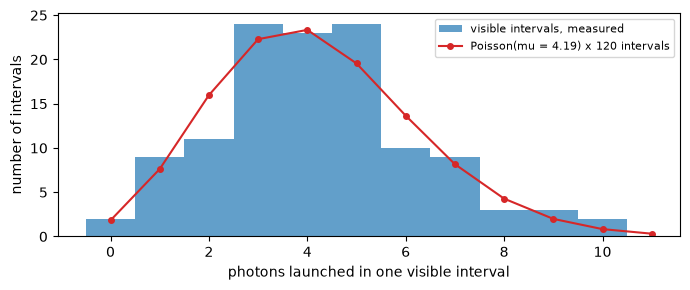

In [14]:
from scipy import stats

interval_livetime = intervals[0].livetime  # identical for every interval here
mu_interval = (flux * comptelito.throwing_plane_size * interval_livetime).to_value(u.dimensionless_unscaled)

occulted_per_interval = np.array([
    earth.is_occulted(sky_angle, iv.orbit_angle, iv.orbit_radius) for iv in intervals])

edges = np.append(interval_starts, intervals[-1].stop_time.to_value(u.s))
counts_per_interval, _ = np.histogram(times, bins = edges)
counts_visible = counts_per_interval[~occulted_per_interval]

k = np.arange(0, counts_visible.max() + 2)
pmf = stats.poisson.pmf(k, mu_interval) * len(counts_visible)

fig, ax = plt.subplots(figsize = (7, 3))
ax.hist(counts_visible, bins = np.arange(-.5, counts_visible.max() + 1.5),
       color = 'tab:blue', alpha = .7, label = 'visible intervals, measured')
ax.plot(k, pmf, 'o-', color = 'tab:red', ms = 4,
       label = f'Poisson(mu = {mu_interval:.2f}) x {len(counts_visible)} intervals')
ax.set_xlabel('photons launched in one visible interval')
ax.set_ylabel('number of intervals')
ax.legend(fontsize = 8)
fig.tight_layout()

print(f"mu_interval (analytic)         = {mu_interval:.3f}")
print(f"visible intervals: mean count  = {counts_visible.mean():.3f}")
print(f"visible intervals: variance    = {counts_visible.var():.3f}   (Poisson: mean == variance)")

Mean and variance of the visible-interval counts sit close together,
as a Poisson distribution demands -- there is no separate "occultation
variance" hiding in there, just the ordinary Poisson scatter of a fixed-mean
draw, applied only where the source was actually visible.

## 6. Where this sits

This notebook covered PR 3 in full: the inertial <-> detector transforms,
`PointSource` and `IsotropicSource` aimed by `sky_angle`, and
`InertialSimulator`'s per-interval Poisson-then-reject loop, including
occultation. What's still missing is everything the plan schedules for
later PRs:

- **PR 4** -- `NearPointSource` (an instrumental source bolted to the
  spacecraft, the inertial-mode analogue of notebook 00's calibration
  source) and `ExtendedSource` (a von Mises glow on the sky, interpolating
  between `PointSource` and `IsotropicSource`).
- **PR 5** -- `EarthAlbedoSource`: gamma rays scattered back off the Earth's
  surface, sampled from the emission point rather than the sky direction
  to dodge the limb's `1/cos(theta)` divergence, and deliberately **not**
  occultable (its photons come from the Earth's direction by construction).
- **PR 6** -- time-dependent source scaling (a lightcurve evaluated at each
  interval's midpoint) and an event-list CSV format for saving a run to
  disk and reading it back.
- **PR 7** -- a YAML configuration format tying a detector, an Earth, an
  `.ori` file and a list of sources into one file, so a full run needs no
  Python beyond `InertialSimulator.from_config(...)`.

Every one of those builds on exactly the machinery this notebook exercised:
a source that knows its own `sky_angle`, a pose that knows the spacecraft's
attitude, and the transform that connects the two.